# Ens'IA - Session 3: Neural network

After having seen how both a neuron and backpropagation works, it is time to do some more serious business and make an ENTIRE neural network. Of course, we won't ask you to reprogram everything from the ground up! In order to build our neural network, we are going to use the famous **[Keras](https://keras.io/) API**! It is an API that makes building neural networks very simple and efficient.

Keras is included in the TensorFlow library through `tf.keras`, so there is no need to import it separately.

In [1]:
import tensorflow as tf # We import TensorFlow
import numpy as np
import matplotlib.pyplot as plt

In order to train a neural network, we need 3 datasets:

1.   A **training set** (80% of total data)
2.   A **validation set** (~10%)
3.   A **test set**   (~10%)

- The **training set** will allow you to train your neural network;
- The **validation set** will allow you to test your neural network during the training process in order to follow its progression;
- We keep an additional **test set** which does not interfere with the training in any way so that you are able to test your neural network after it has been trained.

In [2]:
# Here, we load the training and test sets
# The validation set will have to be created from the training set (we can take 10% of the training set later for that)
mnist = tf.keras.datasets.mnist
(raw_x_train, raw_y_train), (x_test, y_test) = mnist.load_data()

# Taille des jeux de données
print(f"{raw_x_train.shape}") # The training set is composed of 60 000 images of size 28x28
print(f"{x_test.shape}")

11501568/11490434 [==============================] - 0s 0us/step
(60000, 28, 28)
(10000, 28, 28)


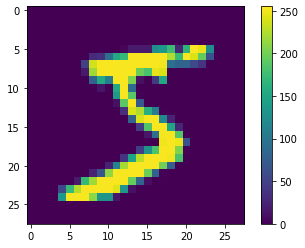

Class: 5


In [3]:
# Let's plot an image
plt.figure()
plt.imshow(raw_x_train[0])
plt.colorbar()
plt.grid(False)
plt.show()
# And print its class (expected output)
print(f"Class: {raw_y_train[0]}")

In order to create our validation set, we will divide the training set into 2 part (90% training, 10% validation). To do that, we will use a function from the **scikit-learn** library that we already used during the first session. Go search in its API how the `train_test_split()` function works!


In [4]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(raw_x_train, raw_y_train, test_size=0.1) # 3 arguments

In [5]:
x_train.shape

(54000, 28, 28)

Do you remember the neural network input? It was under the form of a 1 dimensional vector, so we need to resize all the images (flatten) from (28, 28) to (28 * 28,) = (784,)

In [6]:
x_train = x_train.reshape(54000, 28 * 28)
x_val = x_val.reshape(6000, 28 * 28)
x_test = x_test.reshape(10000, 28 * 28)

And the output? It should the a 1D vector representing the classes (labels) under the one hot encoding form. So we use the `to_categorical()` **Keras** function to transform our classes (0, 1, 2, ..., 9) into one hot encoding.

In [7]:
y_train = tf.keras.utils.to_categorical(y_train)
y_val = tf.keras.utils.to_categorical(y_val)

y_test_no_onehot = y_test # We keep this here for the confusion matrix at the end ;)
y_test = tf.keras.utils.to_categorical(y_test)

We now have 3 datasets: train, val and test.
Now comes the model creation part!

To do that, we are going to create a neural network that takes our images as input and gives us the correct number in output.
So we need an input of size equal to the number of pixels in an image (28x28).
The output will have to be equal to the number of classes (one hot encoding: refer to the slides or ask for help if you did not understand!; 10 because we have 10 numbers).

You will create 3 layers:
* A **dense** layer with **128 neurons** (which takes 28x28 vectors as input)
* A **dense** layer with **64 neurons**
* An output layer, also **dense** with **10 neurons**

You will use the **sigmoid activation function for each dense layer**.
`model.summary()` will allow you to see more clearly with additional details your neural network.

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow import keras

In [9]:
# Create your model here
# See https://keras.io/layers/core/ for details on how to create those layers ;)

model = Sequential([
    # Here goes some layers!
    # keras.layers.something...
    keras.layers.Dense(128, activation='sigmoid', input_shape=(28*28,)),
    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 128)               100480    
_________________________________________________________________
dense_1 (Dense)              (None, 64)                8256      
_________________________________________________________________
dense_2 (Dense)              (None, 10)                650       
Total params: 109,386
Trainable params: 109,386
Non-trainable params: 0
_________________________________________________________________


You have now created a neural network! You now have to specify which loss function and which backpropagation method you want to use.
There are many of them but for this time, we will simply use **SGD** (Stockastic Gradient Descent), **categorical crossentropy** as the loss function and the **accuracy** as an additional metric that we want to display during the training.

In [10]:
from tensorflow.keras import optimizers
from tensorflow.keras import losses

model.compile(
    optimizer=optimizers.SGD(), # you can also try "adam"
    loss=losses.CategoricalCrossentropy(from_logits=False), # you can also try "mse"
    metrics=['accuracy']
)

Everything is now ready to begin the training! Try to train your model on **10 epochs** with a **batch size of 64**.
The bravest ones can also try to specify a learning rate (the default learning rates are pretty good though!).

In [11]:
import time
start = time.time()

history = model.fit(
    x_train, y_train, validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64
)

print(f"Training done in {time.time() - start :.0f} seconds!")

Epoch 1/10
844/844 [==============================] - 6s 4ms/step - loss: 1.7329 - accuracy: 0.6250 - val_loss: 1.2570 - val_accuracy: 0.7883
Epoch 2/10
844/844 [==============================] - 3s 3ms/step - loss: 0.9744 - accuracy: 0.8347 - val_loss: 0.7616 - val_accuracy: 0.8643
Epoch 3/10
844/844 [==============================] - 3s 4ms/step - loss: 0.6450 - accuracy: 0.8768 - val_loss: 0.5521 - val_accuracy: 0.8835
Epoch 4/10
844/844 [==============================] - 3s 4ms/step - loss: 0.4962 - accuracy: 0.8944 - val_loss: 0.4543 - val_accuracy: 0.8958
Epoch 5/10
844/844 [==============================] - 3s 4ms/step - loss: 0.4161 - accuracy: 0.9031 - val_loss: 0.3985 - val_accuracy: 0.9018
Epoch 6/10
844/844 [==============================] - 3s 4ms/step - loss: 0.3681 - accuracy: 0.9109 - val_loss: 0.3636 - val_accuracy: 0.9090
Epoch 7/10
844/844 [==============================] - 3s 4ms/step - loss: 0.3361 - accuracy: 0.9154 - val_loss: 0.3340 - val_accuracy: 0.9110
Epoch 

You can see your neural network make some progress after each step!
So you see the loss, the accuracy on the training set, along with both the loss and the accuracy on the validation set.

The following code allows to plot the evolution of the accuracy and the loss over time. It is always useful to look at the to see how your neural network evolves.

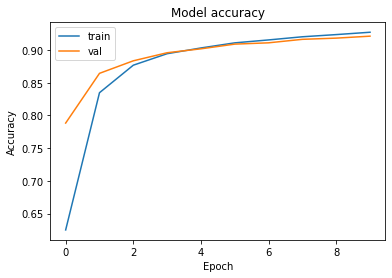

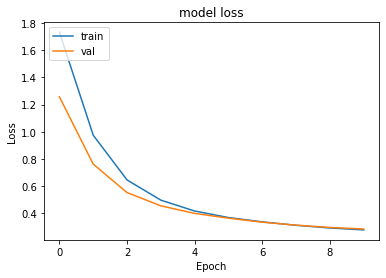

In [12]:
def plot_history(history):
    """
    Plots the accuracy and the loss
    """
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['train', 'val'], loc='upper left')
    plt.show()
    
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['train', 'val'], loc='upper left')
    plt.show()

plot_history(history)

If you see the loss decrease and the accuracy increase, it is usually good!
It is now time to test your neural network on the test dataset by using the `model.evaluate()` method.

In [13]:
# Evaluates your neural network on the test dataset
# Result: [loss, accuracy] (see https://keras.io/api/models/model_training_apis/#evaluate-method)
model.evaluate(x_test, y_test) # Try to print it!

res = model.predict(x_test) # We ask you neural network to predict on the inputs
print(f"Sample prediction -> {res[0]}") # We look at the first prediction

# The output is actually an array of size 10 with each value corresponding to
# the probability that the given image is of the class corresponding to the array index
# In res[0], the index having the highest value is the index 7, so the predicted class is 7
res = np.argmax(res, axis=1) # Argmax gives the index having the highest value (so here we have 7 for res[0])

# Let's look at the confusion matrix using sklearn!
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test_no_onehot, res, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))

313/313 [==============================] - 1s 3ms/step - loss: 0.2713 - accuracy: 0.9287
Sample prediction -> [0.2939069  0.28270727 0.7902443  0.8430627  0.3016115  0.14879647
 0.0160802  0.9986131  0.11249618 0.8390674 ]
[[ 963    0    0    1    0    6    8    1    1    0]
 [   0 1114    2    3    0    0    5    1    9    1]
 [  11    2  952   11   10    0   10    7   27    2]
 [   1    0   22  927    0   30    1    9   14    6]
 [   1    3    3    0  915    0   16    1    4   39]
 [   9    2    6   35    4  790   12    4   21    9]
 [  13    4    6    0    9   14  909    0    3    0]
 [   3   11   24    7    6    0    0  950    1   26]
 [   7    4   12   26   10   18   12    9  860   16]
 [  12    6    5   12   43    6    1   13    4  907]]


In [14]:
m = confusion_matrix(y_test_no_onehot, res, labels=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

import plotly.express as px
import pandas as pd

fig = px.density_heatmap(m, y=m)
fig.show()

Exception: ignored

## To go further

Your neural network should now work quite well but in reality, there are a few problems that may not have appeared here but that may appear depending on the initialization of weights and biases, the dataset, the architecture or other things.

### Activation functions

Until now, each layer had the sigmoid activation function $(\frac{1}{(1+\exp^{-x})})$
![](https://upload.wikimedia.org/wikipedia/commons/thumb/8/88/Logistic-curve.svg/320px-Logistic-curve.svg.png)

Actually, there are others that work better. The problem with **sigmoid** is that when we do the gradient descent, we will calculate the partial derivatives in order to find where to modify the weights of our neurons. However, the derivative of sigmoid for values that are a little too large or too small will be equal to 0... So we end up with a gradient of 0 and our neural network will not train anymore. The same problem occurs with another activation function, **tanh**. This problem is known as "*vanishing gradient*".

Until now we used **sigmoid** but there are many that work much better than this one.

The most commonly used is **ReLU** (Rectified Linear Unit) which function is $ReLU(x) = \max(0, x)$, so the curve is:
<img src=https://cdn-images-1.medium.com/max/1600/1*DfMRHwxY1gyyDmrIAd-gjQ.png width="500">

Why do we use Relu?

1. Inexpensive to calculate
2. No vanishing gradient
3. It is linear and converges faster

Another famous function is **Softmax**. It is often used as the **last** activation function of a neural network.
There are plenty more of them, which some are derivatives of Relu; for instance, **Leaky ReLU** ou **ELU** but in practice, Relu should be enough.

If you really want to go deeper and increase your knowledge on the activation function, go watch the 30 first minutes of https://youtu.be/wEoyxE0GP2M.


## The gradient descent

![](https://blog.paperspace.com/content/images/2018/05/68747470733a2f2f707669676965722e6769746875622e696f2f6d656469612f696d672f70617274312f6772616469656e745f64657363656e742e676966.gif)

Here is what happens in the case of a function in 3 dimensions. Of course, our neural network having many more parameters (sometimes several hundreds of thousands), the dimension is a bit higher.
Moreover, in this case, we can see that everything goes well, from the starting point taken, we manage to find the minimum of the function.
However, this is not always the case with the gradient descent algorithm. It often happens that we find a **LOCAL** minimum when we are really looking for the **global** minimum of the function. This is why other algorithms have been developed. The first idea was to add a momentum to the gradient descent: in other words, we add speed to our gradient descent, so we find the minimum more quickly.

![](https://media.giphy.com/media/SJVFO3IcVC0M0/giphy.gif)

Here is how different algorithms perform to find the minimum of a function. We can see that SGD (the basic gradient descent) is the slowest. **RMSProp** on the other hand, works quite well.

The most used of them is **Adam**. One of the characteristics of Adam is that there is **one learning rate per parameter**. Moreover, it is very easy to configure (most of the time, the default parameters will give you the best possible result)

![](https://3qeqpr26caki16dnhd19sv6by6v-wpengine.netdna-ssl.com/wp-content/uploads/2017/05/Comparison-of-Adam-to-Other-Optimization-Algorithms-Training-a-Multilayer-Perceptron.png)

Here is a comparison of the most popular optimizers. We can see that Adam performs the best. If you want to know everything about Adam and you have some time, [you can read the article here](https://arxiv.org/pdf/1412.6980.pdf). Or if you need more explanations, [check out this video](https://youtu.be/_JB0AO7QxSA) (the first part of the course is about optimizers).

## The dropout

One problem that can happen with your current neural network is that it suffers from **overfitting**. In other words, instead of learning to generalize well on data it has not yet seen (the test set), your neural network will learn the features of the training set and will underperform in the test phase. Imagine that we train a neural network to recognize cats and that on each of the images of the training set, the neural network sees the ears, the tail and the legs. If in the test game it only sees the ears and the paws, it might make a mistake and not identify the image as a cat.

For this, you can add some dropout. In other words, between 2 layers, we will "cut out" some connections. In other words, some neurons of layer $k$ will not send their output to layer $k_{+1}$.

In [ ]:
# Now that you've seen all this, you should be able to build a neural network
# with the following characteristics:
# - For each layer, the activation function should be ReLU except for the last
#   one which will use Softmax
# - The optimizer should be Adam instead of SGD
# - Uses some dropout between each layer

model2 = keras.models.Sequential([
    # Here goes some layers!
])

model2.compile() # And here some params!

history = model2.fit() # Here too :3

model2.evaluate(x_test, y_test) # Your score